In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import math

from qbo1d import adsolver, utils
from qbo1d.stochastic_2wave_forcing import WaveSpectrum
torch.set_default_dtype(torch.float64)

from scipy import signal

In [2]:
def qbo_pattern(data, height_index, height=25, plot=True, if_print=False, index=0):
    idh = np.abs(height_index - height).argmin()
    h = height_index[idh]
    u0 = data[:,idh]
    u0 = (u0 - u0.mean()).flatten()

    # LPF
    dt = 1.
    cutoff = 1. / 120.
    sos = signal.butter(9, cutoff, btype='low', fs=1/dt, output='sos')
    u0 = signal.sosfiltfilt(sos, u0)
    u0 = u0.copy()

    u0 = torch.tensor(u0)

    L = len(u0) / 30
    N = len(u0)

    amps = torch.fft.rfft(u0) / N * 2     
    freq = torch.fft.rfftfreq(N, d=L/N)

    period = 1 / freq

    if plot == True:
        plt.plot(period.numpy(), torch.abs(amps).numpy()**2, label=f'{index}')
        plt.xlim(0,100)
        plt.xlabel('months')
        plt.ylabel('power')
        plt.title(f"1D-QBO FFT spectrum at {h}km")
        plt.grid()

    idx = torch.argmax(torch.abs(amps))
    dominant_period = period[idx].item()

    if if_print == True:
        print(f"Dominant period at {h}km: {dominant_period:.2f} months")

    return amps, period, dominant_period

d:\desktop_file\QBO-FNOs\HamidPahlavan-qbo1d-8e6c775\qbo1d\utils.py:154: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path_to_state_dict))


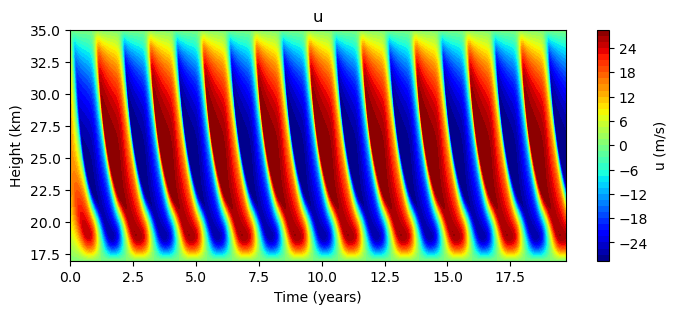

In [5]:
model_time = 20
solver = adsolver.ADSolver(t_max=360*model_time*86400,kappa=3e-1)
u = solver.solve()

time_in_years = np.arange(u.shape[0]) / 365.0
height_in_km = np.linspace(17, 35, u.shape[1])

plt.figure(figsize=(8, 3))
plt.contourf(time_in_years, height_in_km, u.T, cmap='jet', levels=50)
plt.colorbar(label='u (m/s)')
plt.xlabel('Time (years)')
plt.ylabel('Height (km)')
plt.title('u')
plt.show()

In [ ]:
model_time = 120

kappa_value = np.arange(0.05,1.,0.05)
kappa_period = np.zeros(len(kappa_value))
u_amps = []
i = 0

for kappa in kappa_value:

    solver = adsolver.ADSolver(t_max=360*model_time*86400, kappa=kappa)
    u = solver.solve()

    amps = torch.max(torch.abs(u[365:,:]))
    u_amps.append(amps)

    _, _, kappa_period[i] = qbo_pattern(u, height_in_km, height=25, plot=False)

    if kappa_period[i] > 100:
        kappa_period[i] = 0

    i = i + 1


d:\desktop_file\QBO-FNOs\HamidPahlavan-qbo1d-8e6c775\qbo1d\utils.py:154: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path_to_state_dict))


Text(0, 0.5, 'period (months)')

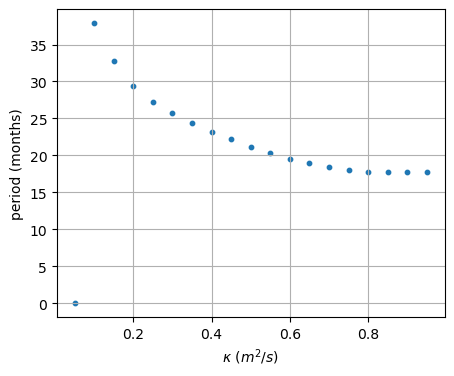

In [21]:
plt.figure(figsize=(5,4))
plt.scatter(kappa_value,kappa_period, s=10)
plt.grid()
plt.xlabel(f'$\kappa \ (m^2/s)$')
plt.ylabel('period (months)')

(0.0, 100.0)

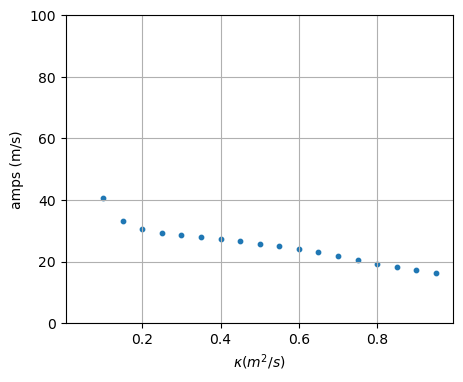

In [ ]:
plt.figure(figsize=(5,4))
plt.scatter(kappa_value, u_amps, s=10)
plt.grid()
plt.xlabel(f'$\kappa \ (m^2/s)$')
plt.ylabel('amps (m/s)')
plt.ylim([0,100])

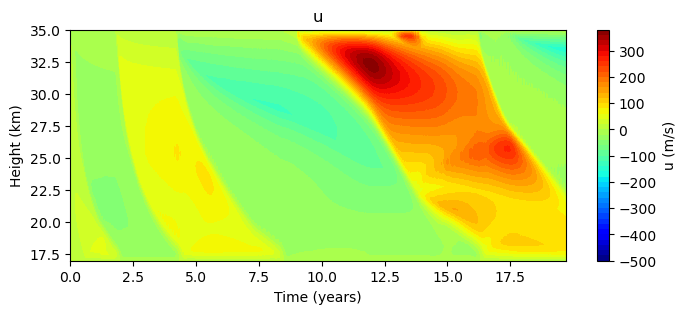

In [25]:
# kappa = 0.05
model_time = 20
kappa = 0.05
solver = adsolver.ADSolver(t_max=360*model_time*86400, kappa=kappa)
u = solver.solve()

time_in_years = np.arange(u.shape[0]) / 365.0
height_in_km = np.linspace(17, 35, u.shape[1])

plt.figure(figsize=(8, 3))
plt.contourf(time_in_years, height_in_km, u.T, cmap='jet', levels=50)
plt.colorbar(label='u (m/s)')
plt.xlabel('Time (years)')
plt.ylabel('Height (km)')
plt.title('u')
plt.show()

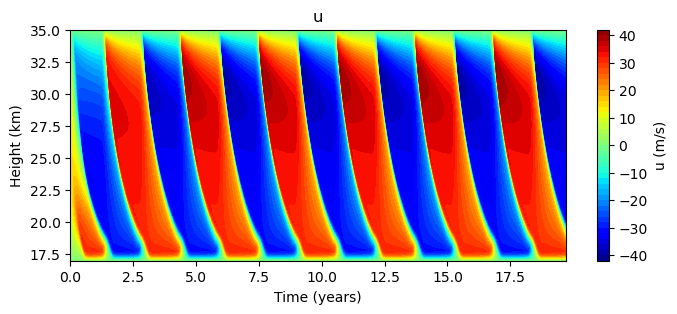

In [17]:
# kappa = 0.1
model_time = 20
kappa = 0.1
solver = adsolver.ADSolver(t_max=360*model_time*86400, kappa=kappa)
u = solver.solve()

time_in_years = np.arange(u.shape[0]) / 365.0
height_in_km = np.linspace(17, 35, u.shape[1])

plt.figure(figsize=(8, 3))
plt.contourf(time_in_years, height_in_km, u.T, cmap='jet', levels=50)
plt.colorbar(label='u (m/s)')
plt.xlabel('Time (years)')
plt.ylabel('Height (km)')
plt.title('u')
plt.show()

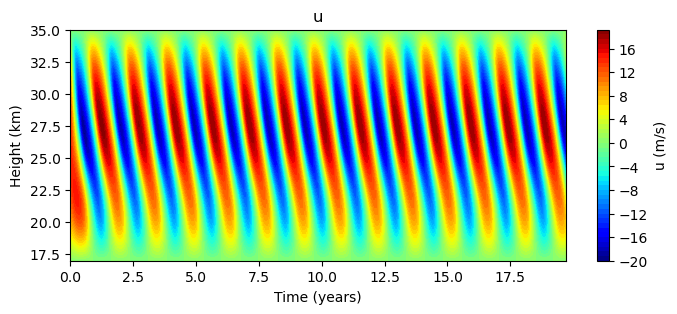

In [18]:
# kappa = 0.8
model_time = 20
kappa = 0.8
solver = adsolver.ADSolver(t_max=360*model_time*86400, kappa=kappa)
u = solver.solve()

time_in_years = np.arange(u.shape[0]) / 365.0
height_in_km = np.linspace(17, 35, u.shape[1])

plt.figure(figsize=(8, 3))
plt.contourf(time_in_years, height_in_km, u.T, cmap='jet', levels=50)
plt.colorbar(label='u (m/s)')
plt.xlabel('Time (years)')
plt.ylabel('Height (km)')
plt.title('u')
plt.show()